In [ ]:
### THIS CELL SETS UP THE GOOGLE COLAB ENVIRONMENT.
### IF RUNNING THIS NOTEBOOK LOCALLY, IT MAY BE SAFELY DELETED.

try:
    import google.colab
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False
except Exception as e:
    raise Exception("Could not figure out if running in a colab notebook\n") from e

if RUNNING_IN_COLAB:
    !pip install dataprob

## Maximum Likelihood fitting

This notebook demonstrates the `ml` fitter, which finds parameters that minimize the
weighted sum of squared residuals using `scipy.optimize.least_squares`. It is the fastest
method and the right starting point for most fitting problems. Parameter uncertainties
are estimated from the local curvature of the likelihood surface (Gauss-Newton Hessian
approximation).

**When to use:** Your parameters are not strongly correlated, or you want a fast point
estimate before running a Bayesian analysis.

### Define model

We use a linear model $y = mx + b$. dataprob infers `m` and `b` as fittable parameters
from their float defaults; `x` is passed as a non-fittable argument.

In [1]:
%matplotlib inline
import dataprob
import numpy as np

def linear_model(m=1, b=1, x=None):
    return m*x + b

### Generate noisy data

We generate 30 observations with known parameters (m = 3, b = 1) and add Gaussian noise
(σ = 0.5). In a real analysis `y_obs` and `y_std` come from your experiment.

In [2]:
true_params = {"m": 3.0, "b": 1.0}

x = np.linspace(0, 10, 30)
y_std = 0.5
y_obs = linear_model(x=x, **true_params) + np.random.normal(0, y_std, size=x.shape)

### Set up and run the fit

All `scipy.optimize.least_squares` keyword arguments can be passed through `f.fit()`.
`num_samples` controls how many parameter vectors are drawn from the covariance matrix
to produce the grey envelope in `plot_summary` and the distributions in `plot_corner`.

In [3]:
f = dataprob.setup(linear_model,
                   method="ml",
                   non_fit_kwargs={"x": x})

f.fit(y_obs=y_obs,
      y_std=y_std,
      num_samples=100000,
      output_dir=None,
      method="trf",
      ftol=1e-8,
      xtol=1e-8,
      gtol=1e-8,
      x_scale=1.0,
      max_nfev=None,
      loss="linear",
      verbose=0)

### Examine fit results

`f.fit_df` reports the ML estimate, standard deviation, and 95% confidence interval for
each parameter. `plot_summary` overlays the fit on the data; `plot_corner` shows the
parameter covariance structure derived from the inverse Hessian.

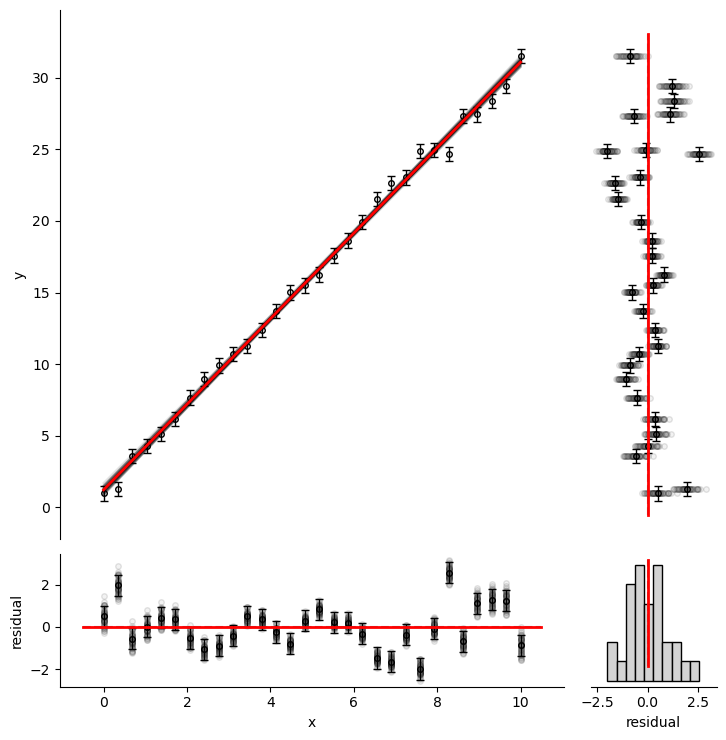

In [4]:
fig = dataprob.plot_summary(f, x_axis=x, x_label="x", y_label="y")

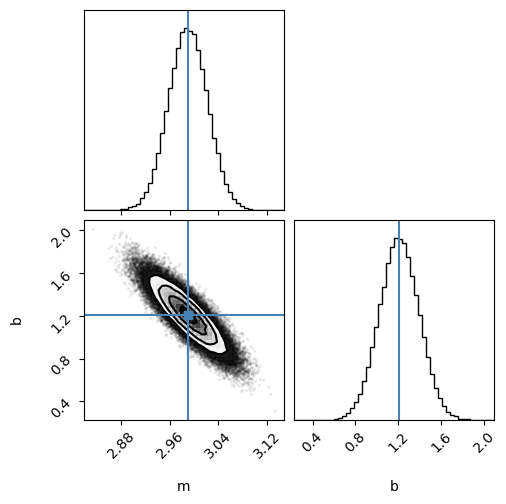

In [5]:
fig = dataprob.plot_corner(f)

In [6]:
f.fit_df

,name,estimate,std,low_95,high_95,guess,fixed,lower_bound,upper_bound,prior_mean,prior_std
name,,,,,,,,,,,
m,m,2.989744,0.031879,2.924442,3.055046,1.0,False,-inf,inf,NaN,NaN
b,b,1.205931,0.185635,0.825674,1.586188,1.0,False,-inf,inf,NaN,NaN


### Assess fit quality

A good ML fit has normally distributed residuals with zero mean and no autocorrelation.
The `reduced_chi2` should be close to 1: values above 1.25 suggest underestimated `y_std`
or model mismatch; values below 0.75 suggest overfitting or overestimated `y_std`.

In [7]:
f.fit_quality

,description,is_good,value,message
name,,,,
success,fit success status,True,True,
num_obs,number of observations,True,30,
num_param,number of fit parameters,True,2,There are 28 more observations than fit parame...
lnL,log likelihood,True,-21.983062,
chi2,chi^2 goodness-of-fit,True,0.295675,A p-value of 2.957e-01 for the a goodness-of-f...
reduced_chi2,reduced chi^2,True,1.126616,A reduced chi^2 value of 1.127 is consistent w...
mean0_resid,t-test for residual mean != 0,True,1.0,A p-value of 1.000e+00 for the one-sample t-te...
durbin-watson,Durbin-Watson test for correlated residuals,True,1.594937,A Durbin-Watson test-statistic of 1.595 is con...
ljung-box,Ljung-Box test for correlated residuals,True,0.192385,A p-value of 1.924e-01 for the Ljung-Box test ...
